In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from IPython.display import display, Markdown

from config import PROCESSED_DATA_DIR

from src.graph.personalized_pagerank import SAMLDRingPersonalizedPageRank

In [2]:
### initialize the pooled Personalized PageRank experiment
# ring experiment directory
ring_experiment_dir = PROCESSED_DATA_DIR / 'graph' / 'ring_expansion_validation'

# create personalized PageRank instance
ppr_experiment = SAMLDRingPersonalizedPageRank(
    experiment_dir = ring_experiment_dir,
    damping = 0.85,
    personalization_scheme = 'uniform_seed'
)

# input summary
input_summary = ppr_experiment.build_input_summary()
display(input_summary)

node_count,edge_count,ring_count,seed_count,candidate_count,target_count,target_rate,damping,personalization_scheme
i64,i64,i64,i64,i64,i64,f64,f64,str
780262,807600,129,249,780013,577,0.00074,0.85,"""uniform_seed"""


**Experimental Design**

`uniform_seed` assigns equal restart probability to every known seed account. The ranking population is every graph node except those seeds. The **577 targets** remain in this population beside approximately **780k unlabeled candidates**, so the target rate is extremely small. This is the correct operational shape for a prioritization test

9 PPR variants will be tested: forward, reverse, and their equal-weight bidirectional blend, each with unweighted, transaction-count, and log-count edges. The blend is included since the notebook 06 (`06_ring_expansion_preparation.ipynb`) found large forward-only and reverse-only target groups. Ordinary PageRank receives the same directional treatments, and simple activity rankings are retained as controls

In [3]:
### build the persisted observation graph and compute all ranking scores
# build igraph
graph = ppr_experiment.build_igraph(
    force_rebuild = False
)

# score table
score_table = ppr_experiment.build_score_table(
    force_recompute = False
)

print(
    f'Graph nodes: {graph.vcount():,}'
)
print(
    f'Graph edges: {graph.ecount():,}'
)
print(
    f'Score-table rows: {score_table.height:,}'
)
display(score_table.head())

Graph nodes: 780,262
Graph edges: 807,600
Score-table rows: 780,262


node_id,account,out_degree,in_degree,total_directed_degree,account_transaction_event_count,is_seed,is_in_seed_weak_component,is_forward_reachable_from_seed,is_reverse_reachable_from_seed,pagerank_unweighted,pagerank_count_weighted,pagerank_log_count_weighted,reverse_pagerank_unweighted,reverse_pagerank_count_weighted,reverse_pagerank_log_count_weighted,bidirectional_pagerank_unweighted,bidirectional_pagerank_count_weighted,bidirectional_pagerank_log_count_weighted,personalized_pagerank_unweighted,personalized_pagerank_count_weighted,personalized_pagerank_log_count_weighted,reverse_personalized_pagerank_unweighted,reverse_personalized_pagerank_count_weighted,reverse_personalized_pagerank_log_count_weighted,bidirectional_personalized_pagerank_unweighted,bidirectional_personalized_pagerank_count_weighted,bidirectional_personalized_pagerank_log_count_weighted
u64,str,u64,u64,u64,u64,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,"""1000005344""",0,1,1,13,false,false,false,false,9.0945e-7,9.3413e-7,9.2660e-7,4.4813e-7,4.7314e-7,4.6322e-7,6.7879e-7,7.0364e-7,6.9491e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"""1000008432""",1,0,1,12,false,false,false,false,8.1270e-7,8.2872e-7,8.2359e-7,0.000001,0.000002,0.000001,0.000001,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"""1000038979""",0,1,1,12,false,false,false,false,0.000001,0.000001,0.000001,4.4813e-7,4.7314e-7,4.6322e-7,7.6200e-7,8.1555e-7,7.9700e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,"""100004626""",1,0,1,12,false,false,false,false,8.1270e-7,8.2872e-7,8.2359e-7,0.000002,0.000002,0.000002,0.000001,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,"""1000065088""",0,1,1,7,false,false,false,false,8.7572e-7,8.7710e-7,8.8407e-7,4.4813e-7,4.7314e-7,4.6322e-7,6.6192e-7,6.7512e-7,6.7364e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
### veryfy score normalization and label separation
# PageRank columns
pagerank_columns = (
    *ppr_experiment.get_ordinary_pagerank_columns(),
    *ppr_experiment.get_personalized_pagerank_columns()
)

# forbidden columns to prevent leakage
forbidden_columns = {
    'ring_id',
    'target_order',
    'is_ring_target'
}

# PageRank score sums
score_sums = (
    score_table
    .select(
        [
            pl.col(column_name)
            .sum()
            .alias(
                column_name
            )
            for column_name in pagerank_columns
        ]
    )
)

score_sums_rows = score_sums.row(
    0,
    named = True
)

assert (
    forbidden_columns.isdisjoint(score_table.columns)
)
assert (
    score_table.height == input_summary['node_count'][0]
)
assert (
    all(
        np.isclose(
            score_sums.get_column(column_name).item(),
            1.0,
            rtol = 1e-8,
            atol = 1e-10
        )
        for column_name in pagerank_columns
    )
)

display(score_sums_rows)
print('\nAll PageRank vectors are normalized and the score table is label-free')

{'pagerank_unweighted': 1.0,
 'pagerank_count_weighted': 1.0,
 'pagerank_log_count_weighted': 0.9999999999999998,
 'reverse_pagerank_unweighted': 1.0,
 'reverse_pagerank_count_weighted': 1.0,
 'reverse_pagerank_log_count_weighted': 1.0,
 'bidirectional_pagerank_unweighted': 0.9999999999999999,
 'bidirectional_pagerank_count_weighted': 1.0,
 'bidirectional_pagerank_log_count_weighted': 1.0,
 'personalized_pagerank_unweighted': 1.0000000000000002,
 'personalized_pagerank_count_weighted': 1.0,
 'personalized_pagerank_log_count_weighted': 0.9999999999999999,
 'reverse_personalized_pagerank_unweighted': 1.0,
 'reverse_personalized_pagerank_count_weighted': 1.0,
 'reverse_personalized_pagerank_log_count_weighted': 0.9999999999999999,
 'bidirectional_personalized_pagerank_unweighted': 1.0000000000000002,
 'bidirectional_personalized_pagerank_count_weighted': 1.0,
 'bidirectional_personalized_pagerank_log_count_weighted': 1.0}


All PageRank vectors are normalized and the score table is label-free


**Leakage check interpretation**

A PageRank sum close to 1 confirms that each result is a valid stationary probability distribution. More importantly, the score table contains no `ring_id`, `target_flag` or `target_order`. PPR uses graph topology, edge weights and seed identifiers; target identifiers enter only in the evaluation table created next

In [5]:
### attach held-out labels after scoring and remove known seeds
# candidate score table
candidate_scores = ppr_experiment.build_candidate_score_table(
    force_recompute = False
)

display(candidate_scores)

# candidate target count
candidate_target_count = int(
    candidate_scores
    .get_column(
        'is_ring_target'
    )
    .sum()
)

assert (
    candidate_scores.height == input_summary['candidate_count'][0]
)
assert (
    candidate_target_count == input_summary['target_count'][0]
)
assert (
    not candidate_scores.get_column('is_seed').any()
)

print(
    f'Ranking candidates: {candidate_scores.height:,}'
)
print(
    f'Held-out targets: {candidate_target_count:,}'
)
print(
    f'Target rate: {candidate_target_count / candidate_scores.height:.6%}'
)


node_id,account,out_degree,in_degree,total_directed_degree,account_transaction_event_count,is_seed,is_in_seed_weak_component,is_forward_reachable_from_seed,is_reverse_reachable_from_seed,pagerank_unweighted,pagerank_count_weighted,pagerank_log_count_weighted,reverse_pagerank_unweighted,reverse_pagerank_count_weighted,reverse_pagerank_log_count_weighted,bidirectional_pagerank_unweighted,bidirectional_pagerank_count_weighted,bidirectional_pagerank_log_count_weighted,personalized_pagerank_unweighted,personalized_pagerank_count_weighted,personalized_pagerank_log_count_weighted,reverse_personalized_pagerank_unweighted,reverse_personalized_pagerank_count_weighted,reverse_personalized_pagerank_log_count_weighted,bidirectional_personalized_pagerank_unweighted,bidirectional_personalized_pagerank_count_weighted,bidirectional_personalized_pagerank_log_count_weighted,ring_id,target_order,is_ring_target
u64,str,u64,u64,u64,u64,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u64,u64,bool
0,"""1000005344""",0,1,1,13,false,false,false,false,9.0945e-7,9.3413e-7,9.2660e-7,4.4813e-7,4.7314e-7,4.6322e-7,6.7879e-7,7.0364e-7,6.9491e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false
1,"""1000008432""",1,0,1,12,false,false,false,false,8.1270e-7,8.2872e-7,8.2359e-7,0.000001,0.000002,0.000001,0.000001,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false
2,"""1000038979""",0,1,1,12,false,false,false,false,0.000001,0.000001,0.000001,4.4813e-7,4.7314e-7,4.6322e-7,7.6200e-7,8.1555e-7,7.9700e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false
3,"""100004626""",1,0,1,12,false,false,false,false,8.1270e-7,8.2872e-7,8.2359e-7,0.000002,0.000002,0.000002,0.000001,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false
4,"""1000065088""",0,1,1,7,false,false,false,false,8.7572e-7,8.7710e-7,8.8407e-7,4.4813e-7,4.7314e-7,4.6322e-7,6.6192e-7,6.7512e-7,6.7364e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
780257,"""9999958143""",0,1,1,13,false,false,false,false,0.000001,0.000001,0.000001,4.4813e-7,4.7314e-7,4.6322e-7,7.6961e-7,8.1464e-7,8.0295e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false
780258,"""9999967460""",0,1,1,1,false,false,false,false,0.000001,8.9601e-7,0.000001,4.4813e-7,4.7314e-7,4.6322e-7,9.0816e-7,6.8458e-7,7.4040e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false
780259,"""9999971095""",0,1,1,12,false,false,false,false,0.000001,0.000001,0.000001,4.4813e-7,4.7314e-7,4.6322e-7,7.8800e-7,8.7053e-7,8.3881e-7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,null,null,false


Ranking candidates: 780,013
Held-out targets: 577
Target rate: 0.073973%


In [6]:
### inspect where pooled PPR probability mass is concentrated
# personalized PageRank columns
ppr_columns = ppr_experiment.get_personalized_pagerank_columns()

score_mass_summary = ppr_experiment.get_score_mass_summary(
    score_columns = ppr_columns
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 100,
    tbl_width_chars = -1
):
    display(
        score_mass_summary
        .sort(
            by = 'target_share_of_candidate_mass',
            descending = True
        )
    )

score_name,total_score_mass,seed_score_mass,candidate_score_mass,target_score_mass,target_share_of_candidate_mass
str,f64,f64,f64,f64,f64
"""personalized_pagerank_unweighted""",1.0,0.534426,0.465574,0.048928,0.105092
"""bidirectional_personalized_pagerank_unweighted""",1.0,0.518799,0.481201,0.047265,0.098223
"""reverse_personalized_pagerank_unweighted""",1.0,0.503172,0.496828,0.045602,0.091786
"""reverse_personalized_pagerank_log_count_weighted""",1.0,0.513992,0.486008,0.034815,0.071635
"""bidirectional_personalized_pagerank_log_count_weighted""",1.0,0.527735,0.472265,0.032196,0.068174
"""personalized_pagerank_log_count_weighted""",1.0,0.541478,0.458522,0.029577,0.064506
"""reverse_personalized_pagerank_count_weighted""",1.0,0.521476,0.478524,0.028414,0.059379
"""bidirectional_personalized_pagerank_count_weighted""",1.0,0.533517,0.466483,0.023327,0.050007
"""personalized_pagerank_count_weighted""",1.0,0.545558,0.454442,0.018241,0.040138


**Score-mass interpretation**

`seed_score_mass` measures how strongly the restart mechanism keeps probability near known accounts. `target_share_of_candidate_mass` measures how much of the non-seed probability reaches withheld ring members. A useful variant should allocate targets a much larger share of candidate mass than their raw population share. Concentrated probability can still be distributed among the wrong targets, so ranking metrics remain decisive

A direction with low target mass is consistent with the directional reachability limits observed in notebook 06. Forward and reverse results should therefore be treated as complementary rather than interchangeable

In [7]:
### compare target and non-target PPR score distributions
# candidate score summary
candidate_score_summary = ppr_experiment.get_candidate_score_summary(
    score_columns = ppr_columns
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 100,
    tbl_width_chars = -1

):
    display(candidate_score_summary)

score_name,population,account_count,minimum,mean,median,p95,p99,maximum,zero_share
str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""personalized_pagerank_unweighted""","""all_candidates""",780013,0.0,5.9688e-7,0.0,0.0,0.0,0.005532,0.990096
"""personalized_pagerank_unweighted""","""ring_targets""",577,0.0,0.000085,0.000016,0.000277,0.000519,0.001251,0.450607
"""personalized_pagerank_unweighted""","""non_targets""",779436,0.0,5.3455e-7,0.0,0.0,0.0,0.005532,0.990496
"""personalized_pagerank_count_weighted""","""all_candidates""",780013,0.0,5.8261e-7,0.0,0.0,0.0,0.005309,0.990096
"""personalized_pagerank_count_weighted""","""ring_targets""",577,0.0,0.000032,6.9296e-7,0.000153,0.00031,0.001911,0.450607
"""personalized_pagerank_count_weighted""","""non_targets""",779436,0.0,5.5964e-7,0.0,0.0,0.0,0.005309,0.990496
"""personalized_pagerank_log_count_weighted""","""all_candidates""",780013,0.0,5.8784e-7,0.0,0.0,0.0,0.00537,0.990096
"""personalized_pagerank_log_count_weighted""","""ring_targets""",577,0.0,0.000051,0.000004,0.000189,0.000394,0.001586,0.450607
"""personalized_pagerank_log_count_weighted""","""non_targets""",779436,0.0,5.5033e-7,0.0,0.0,0.0,0.00537,0.990496


**Distribution interpretation**

Targets should ideally have higher mean and upper-tail scores than non-targets. The `zero_share` is equally important: a zero-scored target is not directionally reachable from any pooled seed under that graph orientation. Its later rank is determined only by the deterministic node id tie break among zero-score accounts, so differences deep in the ranking should not be overinterpreted

In [8]:
### evaluate global account prioritization
k_values = (
    100,
    500,
    1_000,
    5_000,
    10_000
)

# global ranking evaluation
global_evaluation = (
    ppr_experiment
    .evaluate_global_rankings(
        k_values = k_values,
        score_columns = ppr_experiment.get_score_columns()
    )
    .with_columns(
        # method family
        pl.when(
            pl.col('score_name')
            .str
            .contains('personalized')
        )
        .then(
            pl.lit('Personalized PageRank')
        )
        .when(
            pl.col('score_name')
            .str
            .contains('pagerank')
        )
        .then(
            pl.lit('Ordinary PageRank')
        )
        .otherwise(
            pl.lit('Reference ranking')
        )
        .alias(
            'method_family'
        )
    )
)

# best ranking scores at k
comparison_k = 1_000
best_at_comparison_k = (
    global_evaluation
    .filter(
        pl.col('requested_k') == comparison_k        
    )
    .sort(
        [
            'method_family',
            'recall_at_k',
            'ndcg_at_k'
        ],
        descending = [
            False,
            True,
            True
        ]
    )
    .group_by(
        'method_family',
        maintain_order = True
    )
    .first()
)

with pl.Config(
    tbl_cols = -1,
    fmt_str_lengths = 100,
    tbl_width_chars = -1
):
    display(best_at_comparison_k)

method_family,score_name,requested_k,effective_k,candidate_count,target_count,target_rate,hit_count,precision_at_k,recall_at_k,lift_at_k,ndcg_at_k
str,str,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64
"""Ordinary PageRank""","""pagerank_count_weighted""",1000,1000,780013,577,0.00074,17,0.017,0.029463,22.981319,0.023392
"""Personalized PageRank""","""personalized_pagerank_unweighted""",1000,1000,780013,577,0.00074,210,0.21,0.363951,283.88688,0.308321
"""Reference ranking""","""in_degree""",1000,1000,780013,577,0.00074,5,0.005,0.008666,6.759211,0.006962


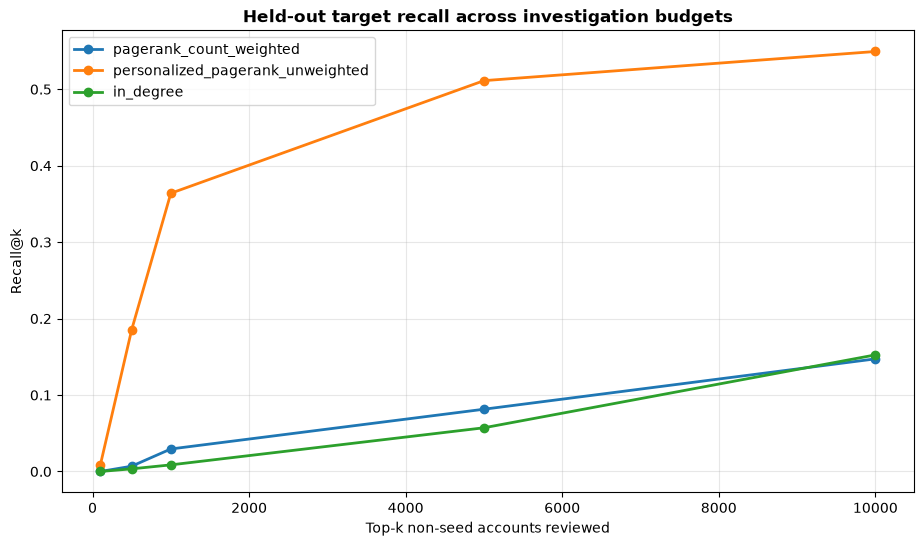

In [9]:
### visualize recall across investigation budgets
# score names
selected_score_names = (
    best_at_comparison_k
    .get_column('score_name')
    .to_list()
)

fig, ax = plt.subplots(figsize = (11, 6))

for score_name in selected_score_names:
    # method results
    method_results = (
        global_evaluation
        .filter(
            pl.col('score_name') == score_name
        )
        .sort(
            'effective_k'
        )
    )

    ax.plot(
        method_results.get_column('effective_k').to_list(),
        method_results.get_column('recall_at_k').to_list(),
        marker = 'o',
        linewidth = 2,
        label = score_name
    )

ax.set_title('Held-out target recall across investigation budgets', fontweight = 'bold')
ax.set_xlabel('Top-k non-seed accounts reviewed')
ax.set_ylabel('Recall@k')
ax.grid(alpha = 0.3)
ax.legend()
plt.show()

In [10]:
### generate the principal account-ranking interpretation
# comparison rows
comparison_rows = {
    row['method_family']: row
    for row in best_at_comparison_k.iter_rows(named = True)
}

best_ppr = comparison_rows['Personalized PageRank']
best_ordinary = comparison_rows['Ordinary PageRank']
best_reference = comparison_rows['Reference ranking']

# recall gain
ppr_recall_gain = (
    best_ppr['recall_at_k'] - best_ordinary['recall_at_k']
)

# hit gain
ppr_hit_gain = (
    best_ppr['hit_count'] - best_ordinary['hit_count']
)

display(
    Markdown(
        f"""
**Global-ranking interpretation at k={comparison_k:,}**

The best pooled PPR variant is **`{best_ppr['score_name']}`**. It finds **{best_ppr['hit_count']:,}** of the {best_ppr['target_count']:,} held-out accounts, 
giving **{best_ppr['recall_at_k']:.1%} recall**, **{best_ppr['precision_at_k']:.1%} precision**, and **{best_ppr['lift_at_k']:.1f}x lift** over random selection

The strongest ordinary PageRank variant is **`{best_ordinary['score_name']}`**, with **{best_ordinary['recall_at_k']:.1%} recall**. Pooled personalization 
therefore changes recall by **{ppr_recall_gain:+.1%}** ({ppr_hit_gain:+,} targets) at the same review budget. The strongest non-PageRank reference is 
**`{best_reference['score_name']}`**, with **{best_reference['recall_at_k']:.1%} recall**

Lift above 1 means the ranking enriches targets relative to their base rate. NDCG additionally rewards placing those targets earlier inside the top-k. 
PPR is supported as a useful baseline only if it improves meaningfully on both ordinary PageRank and the simple reference rankings at operationally relevant k values
"""
    )
)




**Global-ranking interpretation at k=1,000**

The best pooled PPR variant is **`personalized_pagerank_unweighted`**. It finds **210** of the 577 held-out accounts, 
giving **36.4% recall**, **21.0% precision**, and **283.9x lift** over random selection

The strongest ordinary PageRank variant is **`pagerank_count_weighted`**, with **2.9% recall**. Pooled personalization 
therefore changes recall by **+33.4%** (+193 targets) at the same review budget. The strongest non-PageRank reference is 
**`in_degree`**, with **0.9% recall**

Lift above 1 means the ranking enriches targets relative to their base rate. NDCG additionally rewards placing those targets earlier inside the top-k. 
PPR is supported as a useful baseline only if it improves meaningfully on both ordinary PageRank and the simple reference rankings at operationally relevant k values


In [11]:
### inspect complete-ranking target positions
# target rank evaluation
target_rank_evaluation = (
    ppr_experiment.evaluate_target_ranks(
        score_columns = ppr_experiment.get_score_columns()
    )
    .sort(
        [
            'average_precision',
            'median_target_rank'
        ],
        descending = [
            True,
            False
        ]
    )
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 100,
    tbl_width_chars = -1
):
    display(target_rank_evaluation)

score_name,candidate_count,target_count,best_target_rank,median_target_rank,mean_target_rank,p90_target_rank,worst_target_rank,median_target_rank_share,mean_reciprocal_rank,average_precision
str,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64
"""bidirectional_personalized_pagerank_unweighted""",780013,577,18,1523.0,20421.875217,5539.4,700667,0.001953,0.055556,0.121711
"""personalized_pagerank_unweighted""",780013,577,12,3715.0,181580.282496,596420.4,780008,0.004763,0.083333,0.089708
"""bidirectional_personalized_pagerank_log_count_weighted""",780013,577,19,3740.0,21421.847487,6112.8,700667,0.004795,0.052632,0.077533
"""bidirectional_personalized_pagerank_count_weighted""",780013,577,20,4624.0,22077.72617,7525.0,700667,0.005928,0.05,0.061828
"""reverse_personalized_pagerank_unweighted""",780013,577,17,108677.0,222708.114385,623377.6,775419,0.139327,0.058824,0.043771
"""personalized_pagerank_log_count_weighted""",780013,577,6,4772.0,182163.145581,596420.4,780008,0.006118,0.166667,0.038141
"""reverse_personalized_pagerank_log_count_weighted""",780013,577,18,108677.0,222813.538995,623377.6,775419,0.139327,0.055556,0.035926
"""reverse_personalized_pagerank_count_weighted""",780013,577,18,108677.0,222874.97227,623377.6,775419,0.139327,0.055556,0.032783
"""personalized_pagerank_count_weighted""",780013,577,5,5271.0,182447.746967,596420.4,780008,0.006758,0.2,0.029337


**Complete-ranking interpretation**

Average precision summarizes enrichment across all target ranks and is the most useful complete-ranking metric. `best_target_rank` shows how quickly the first true target appears, while median and p90 target rank reveal whether performance extends beyond a small number of easy cases. The reported reciprocal rank concerns the first target in this one pooled ranking; it is not an average across rings. Zero-score ties make deep-rank statistics less stable, so the fixed-budget results above remain primary

In [12]:
### evaluate how broadly the global rankings recover approximate rings
# evaluate ring recovery
ring_recovery_evaluation = ppr_experiment.evaluate_ring_recovery(
    k_values = k_values,
    score_columns = ppr_experiment.get_score_columns()
)

# best ring recovery at k
best_ring_recovery_at_k = (
    ring_recovery_evaluation
    .filter(
        pl.col('requested_k') == comparison_k
    )
    .sort(
        [
            'ring_hit_rate',
            'mean_ring_target_recall',
            'fully_recovered_ring_rate'
        ],
        descending = True
    )
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1,
    fmt_str_lengths = 100,
    tbl_width_chars = -1
):
    display(best_ring_recovery_at_k)

score_name,requested_k,effective_k,ring_count,recovered_target_count,ring_hit_count,ring_hit_rate,fully_recovered_ring_count,fully_recovered_ring_rate,mean_ring_target_recall,median_ring_target_recall,mean_first_hit_rank
str,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,f64
"""bidirectional_personalized_pagerank_unweighted""",1000,1000,129,134,65,0.503876,15,0.116279,0.277439,0.125,591.538462
"""personalized_pagerank_unweighted""",1000,1000,129,210,64,0.496124,28,0.217054,0.345669,0.0,442.578125
"""bidirectional_personalized_pagerank_log_count_weighted""",1000,1000,129,99,61,0.472868,8,0.062016,0.220604,0.0,669.065574
"""reverse_personalized_pagerank_unweighted""",1000,1000,129,104,60,0.465116,5,0.03876,0.212766,0.0,464.583333
"""reverse_personalized_pagerank_log_count_weighted""",1000,1000,129,94,55,0.426357,5,0.03876,0.195878,0.0,526.218182
"""reverse_personalized_pagerank_count_weighted""",1000,1000,129,84,52,0.403101,4,0.031008,0.175197,0.0,552.288462
"""bidirectional_personalized_pagerank_count_weighted""",1000,1000,129,69,44,0.341085,4,0.031008,0.149554,0.0,616.136364
"""personalized_pagerank_log_count_weighted""",1000,1000,129,88,32,0.248062,6,0.046512,0.153242,0.0,434.46875
"""personalized_pagerank_count_weighted""",1000,1000,129,41,18,0.139535,3,0.023256,0.072505,0.0,368.888889


In [13]:
### macro ring-recovery interpretation
best_ring_row = best_ring_recovery_at_k.row(
    0,
    named = True
)

display(
    Markdown(
        f"""
**Ring-recovery interpretation at k={comparison_k:,}**

The strongest result by ring hit rate is **`{best_ring_row['score_name']}`**. The global review list contains at least one withheld member 
from **{best_ring_row['ring_hit_count']:,} of {best_ring_row['ring_count']:,} rings ({best_ring_row['ring_hit_rate']:.1%})**. It fully recovers 
**{best_ring_row['fully_recovered_ring_count']:,} rings ({best_ring_row['fully_recovered_ring_rate']:.1%})**, and its mean per-ring target recall 
is **{best_ring_row['mean_ring_target_recall']:.1%}**

Ring hit rate measures breadth across cases; mean ring target recall measures depth within a typical ring; full recovery is the strictest criterion. 
These metrics aggregate one pooled global ranking by approximate ring. They do **not** show that a target was reached specifically from a seed in 
its own ring. That stronger attribution question belongs in the later local case-investigation stage
"""
    )
)


**Ring-recovery interpretation at k=1,000**

The strongest result by ring hit rate is **`bidirectional_personalized_pagerank_unweighted`**. The global review list contains at least one withheld member 
from **65 of 129 rings (50.4%)**. It fully recovers 
**15 rings (11.6%)**, and its mean per-ring target recall 
is **27.7%**

Ring hit rate measures breadth across cases; mean ring target recall measures depth within a typical ring; full recovery is the strictest criterion. 
These metrics aggregate one pooled global ranking by approximate ring. They do **not** show that a target was reached specifically from a seed in 
its own ring. That stronger attribution question belongs in the later local case-investigation stage


In [14]:
### inspect the highest-ranked candidates from the best PPR variant
best_ppr_score_name = best_ppr['score_name']

# top PPR accounts
top_ppr_accounts = ppr_experiment.get_top_ranked_accounts(
    score_column = best_ppr_score_name,
    top_n = 25
)

with pl.Config(
    tbl_cols = -1,
    tbl_rows = -1
):
    display(top_ppr_accounts)

global_rank,node_id,account,personalized_pagerank_unweighted,is_ring_target,ring_id,target_order,out_degree,in_degree,total_directed_degree,account_transaction_event_count,is_in_seed_weak_component,is_forward_reachable_from_seed,is_reverse_reachable_from_seed
u32,u64,str,f64,bool,u64,u64,u64,u64,u64,u64,bool,bool,bool
1,402277,"""5632446313""",0.005532,false,null,null,1,1,2,4,true,true,true
2,707181,"""9153128438""",0.001876,false,null,null,1,1,2,2,true,true,false
3,359033,"""5132786366""",0.001595,false,null,null,0,1,1,1,true,true,false
4,598489,"""7901404180""",0.001418,false,null,null,1,1,2,2,true,true,false
5,575616,"""7635866133""",0.001418,false,null,null,1,1,2,4,true,true,true
6,242546,"""3790041873""",0.001291,false,null,null,1,1,2,2,true,true,true
7,334397,"""4848609813""",0.001291,false,null,null,0,1,1,7,true,true,false
8,757561,"""9735591723""",0.001291,false,null,null,1,1,2,4,true,true,true
9,676521,"""8799791564""",0.00127,false,null,null,0,1,1,1,true,true,false


**Top-account interpretation**

This table makes the ranking operational, it shows which non-seed accounts an investigator would review first. Target flags are displayed only for retrospective evaluation. High-ranked non-targets are not necessarily genuine false positives since SAML-D labels only generated laundering activity; they may be structurally close legitimate accounts, hubs, or unlabelled intermediaries. Degree and reachability fields help distinguish these explanations

In [15]:
### persist the label-free score table
# score path
score_output_path = ring_experiment_dir / 'personalized_pagerank_scores.parquet'

# write score table to score path
saved_score_path = ppr_experiment.write_score_table(
    output_path = score_output_path,
    overwrite = False
)

# validate score file
ppr_experiment.validate_score_file(
    output_path = saved_score_path
)

**Conclusion**

Pooled Personalized PageRank should be retained if it produces useful lift and ring coverage at realistic review budgets and materially improves on ordinary PageRank and activity-based controls. A forward/reverse difference is expected because notebook 06 showed strongly asymmetric reachability. Edge weighting should be treated as an empirical choice rather than assumed to help

The persisted file contains only graph-derived scores and seed/reachability metadata. At the next step of this project, we should inspect representative successes and failures, combine the best PPR scores with degree, reachability, and compact structural features, and then evaluate a supervised ranking model without using `laundering_type` as an input
